# Trabajo 2 Marketing: Segmentación Starbucks America

Este Notebook desarrolla un análisis de segmentación de mercado para el caso Starbucks America, utilizando el dataset transaccional `s_order.csv`. El objetivo es identificar segmentos de clientes relevantes mediante técnicas de segmentación RFM y socio-demográfica, con el fin de apoyar decisiones estratégicas de mercado, posicionamiento y potencial expansión de franquicias.

El análisis considera la carga y exploración de datos, limpieza inicial, creación de variables, aplicación de modelos K-Means, comparación de segmentos, identificación de mercados meta y recomendaciones estratégicas.

## Importación de librerías 

En esta sección se importan las librerías necesarias para manipulación de datos, visualización, preprocesamiento, segmentación mediante K-Means y evaluación de modelos.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Librerias importadas correctamente")

Librerias importadas correctamente


## Carga del dataset

En esta sección se carga el archivo `s_order.csv`, correspondiente al registro transaccional del caso Starbucks America.

In [2]:
#Cargar el dataset
try:
    df = pd.read_csv("s_order.csv")
    print("Archivo s_order.csv cargado correctamente")
except FileNotFoundError:
    print("No se encontró el archivo s_order.csv")
    print("Verifica que el archivo esté en la misma carpeta del Notebook")

print(f"\nCantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

display(df.head())

Archivo s_order.csv cargado correctamente

Cantidad de filas: 100000
Cantidad de columnas: 20


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


## Exploración inicial del dataset

En esta sección se revisa la estructura general de la base, incluyendo cantidad de filas y columnas, tipos de variables, valores nulos, duplicados y estadísticas descriptivas.

In [3]:
#Exploración del dataset

print("Información general del dataset:")
df.info()

print("\nPrimeras 5 filas:")
display(df.head())

print("\nÚltimas 5 filas:")
display(df.tail())

print("\nResumen estadístico de variables numéricas:")
display(df.describe())

print("\nCantidad de valores nulos por columna:")
display(df.isnull().sum())

print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  tota

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3



Últimas 5 filas:


,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
99995,CUST_09857,ORD_00099996,2025-09-17,17:08,Wed,Mobile App,STR_016,Suburban,Northeast,45-54,Non-binary,True,4,0,15.18,3.2,Frappuccino,False,True,4
99996,CUST_09970,ORD_00099997,2024-08-03,08:07,Sat,Drive-Thru,STR_409,Rural,Southwest,35-44,Prefer not to say,True,5,2,16.71,5.5,Espresso,False,False,3
99997,CUST_04417,ORD_00099998,2025-01-11,16:05,Sat,In-Store Cashier,STR_191,Suburban,Northeast,55+,Female,False,3,0,9.12,3.3,Espresso,False,False,1
99998,CUST_07997,ORD_00099999,2025-10-23,18:32,Thu,Mobile App,STR_210,Rural,Southeast,18-24,Female,True,5,1,18.02,1.9,Other,False,False,2
99999,CUST_07625,ORD_00100000,2024-09-01,13:18,Sun,In-Store Cashier,STR_217,Rural,West,55+,Female,False,1,0,5.29,3.1,Brewed Coffee,True,False,5



Resumen estadístico de variables numéricas:


,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,3.741510,1.81077,14.866771,4.546080,3.687530
std,1.697817,1.46280,5.506800,1.550269,1.184123
min,1.000000,0.00000,3.510000,1.000000,1.000000
25%,3.000000,1.00000,10.837500,3.400000,3.000000
50%,4.000000,2.00000,14.170000,4.400000,4.000000
75%,5.000000,3.00000,18.180000,5.500000,5.000000
max,10.000000,8.00000,40.310000,11.200000,5.000000



Cantidad de valores nulos por columna:


customer_id              0
order_id                 0
order_date               0
order_time               0
day_of_week              0
order_channel            0
store_id                 0
store_location_type      0
region                   0
customer_age_group       0
customer_gender          0
is_rewards_member        0
cart_size                0
num_customizations       0
total_spend              0
fulfillment_time_min     0
drink_category           0
has_food_item            0
order_ahead              0
customer_satisfaction    0
dtype: int64


Cantidad de filas duplicadas:
0


In [4]:
#Revisión de variables categóricas 

categorical_cols = [
    "day_of_week",
    "order_channel",
    "store_location_type",
    "region",
    "customer_age_group",
    "customer_gender",
    "is_rewards_member",
    "drink_category",
    "has_food_item",
    "order_ahead"
]

for col in categorical_cols:
    print("="*60)
    print(f"Variable: {col}")
    print("="*60)
    print(df[col].value_counts(dropna=False))
    print("\n")

Variable: day_of_week
day_of_week
Sat    14443
Mon    14386
Tue    14385
Fri    14277
Thu    14214
Sun    14175
Wed    14120
Name: count, dtype: int64


Variable: order_channel
order_channel
Mobile App          42521
Drive-Thru          27996
In-Store Cashier    22063
Kiosk                7420
Name: count, dtype: int64


Variable: store_location_type
store_location_type
Suburban    35696
Urban       32584
Rural       31720
Name: count, dtype: int64


Variable: region
region
West         22608
Southeast    20223
Southwest    19663
Midwest      19470
Northeast    18036
Name: count, dtype: int64


Variable: customer_age_group
customer_age_group
25-34    29782
35-44    24543
18-24    20274
45-54    15382
55+      10019
Name: count, dtype: int64


Variable: customer_gender
customer_gender
Female               45306
Male                 44767
Non-binary            5058
Prefer not to say     4869
Name: count, dtype: int64


Variable: is_rewards_member
is_rewards_member
False    52283
True    

In [5]:
resumen_categoricas = pd.DataFrame({
    "Variable": categorical_cols,
    "Cantidad de categorías": [df[col].nunique() for col in categorical_cols],
    "Categoría más frecuente": [df[col].mode()[0] for col in categorical_cols],
    "Frecuencia categoría principal": [df[col].value_counts().iloc[0] for col in categorical_cols],
    "Porcentaje categoría principal": [
        round(df[col].value_counts(normalize=True).iloc[0] * 100, 2) 
        for col in categorical_cols
    ]
})

display(resumen_categoricas)

,Variable,Cantidad de categorías,Categoría más frecuente,Frecuencia categoría principal,Porcentaje categoría principal
0,day_of_week,7,Sat,14443,14.44
1,order_channel,4,Mobile App,42521,42.52
2,store_location_type,3,Suburban,35696,35.70
3,region,5,West,22608,22.61
4,customer_age_group,5,25-34,29782,29.78
5,customer_gender,4,Female,45306,45.31
6,is_rewards_member,2,False,52283,52.28
7,drink_category,6,Refresher,16808,16.81
8,has_food_item,2,False,68419,68.42
9,order_ahead,2,False,70207,70.21


In [6]:
#Conversión de fechas 

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

print("Tipo de dato de order_date:")
print(df["order_date"].dtype)

print("\nFecha mínima:")
print(df["order_date"].min())

print("\nFecha máxima:")
print(df["order_date"].max())

Tipo de dato de order_date:
datetime64[ns]

Fecha mínima:
2024-01-01 00:00:00

Fecha máxima:
2025-12-30 00:00:00


## Limpieza inicial del dataset

En esta sección se revisan duplicados, valores nulos y registros críticos para asegurar que la base esté preparada para el análisis posterior.

In [7]:
# Limpieza inicial de datos

# Eliminar duplicados 
df = df.drop_duplicates()

# Eliminar registros críticos sin identificador o fecha
df = df.dropna(subset=["customer_id", "order_id", "order_date"])

# Verificar valores nulos después de la limpieza
print("Valores nulos por columna después de la limpieza:")
display(df.isnull().sum())

print("\nCantidad de filas duplicadas después de la limpieza:")
print(df.duplicated().sum())

print("\nDimensión final del dataset:")
print(df.shape)

Valores nulos por columna después de la limpieza:


customer_id              0
order_id                 0
order_date               0
order_time               0
day_of_week              0
order_channel            0
store_id                 0
store_location_type      0
region                   0
customer_age_group       0
customer_gender          0
is_rewards_member        0
cart_size                0
num_customizations       0
total_spend              0
fulfillment_time_min     0
drink_category           0
has_food_item            0
order_ahead              0
customer_satisfaction    0
dtype: int64


Cantidad de filas duplicadas después de la limpieza:
0

Dimensión final del dataset:
(100000, 20)


In [8]:
# Creación de variables temporales

# Asegurar que order_date esté en formato fecha
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Crear hora del pedido desde order_time
df["order_hour"] = pd.to_datetime(df["order_time"], format="%H:%M", errors="coerce").dt.hour

# Crear tramo horario del pedido
df["time_slot"] = pd.cut(
    df["order_hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Madrugada", "Mañana", "Tarde", "Noche"],
    right=False
)

# Variables temporales adicionales
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day

print("Variables temporales creadas correctamente")

display(df[["order_date", "order_time", "order_hour", "time_slot", "year", "month", "day"]].head())

Variables temporales creadas correctamente


,order_date,order_time,order_hour,time_slot,year,month,day
0,2024-03-25,08:47,8,Mañana,2024,3,25
1,2025-07-18,08:02,8,Mañana,2025,7,18
2,2025-01-15,05:40,5,Madrugada,2025,1,15
3,2024-07-30,15:10,15,Tarde,2024,7,30
4,2024-06-18,07:38,7,Mañana,2024,6,18


In [9]:
# función para obtener categoría principal

def moda_principal(x):
    """
    Retorna la categoría más frecuente de una variable.
    Si hay empate, toma la primera.
    """
    return x.mode().iloc[0] if not x.mode().empty else np.nan

## Ingeniería de variables para segmentación

En esta sección se construyen nuevas variables a nivel de cliente a partir del dataset transaccional. Dado que la base original contiene una fila por pedido, se agregan los datos para obtener una base donde cada fila representa a un cliente.

Se crean variables RFM, variables de comportamiento de compra, variables de experiencia y variables categóricas principales, tales como región dominante, canal principal, categoría de bebida más frecuente y tramo horario de consumo.

In [10]:
#construcción de base a nivel cliente
# Fecha de referencia para calcular recencia
fecha_referencia = df["order_date"].max() + pd.Timedelta(days=1)

customer_features = df.groupby("customer_id").agg(
    
    # Variables RFM
    recency=("order_date", lambda x: (fecha_referencia - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("total_spend", "sum"),
    
    # Variables de comportamiento de compra
    avg_ticket=("total_spend", "mean"),
    avg_cart_size=("cart_size", "mean"),
    avg_customizations=("num_customizations", "mean"),
    avg_fulfillment_time=("fulfillment_time_min", "mean"),
    avg_satisfaction=("customer_satisfaction", "mean"),
    
    # Proporciones de comportamiento
    food_order_rate=("has_food_item", "mean"),
    order_ahead_rate=("order_ahead", "mean"),
    
    # Variables categóricas principales por cliente
    main_region=("region", moda_principal),
    main_store_location_type=("store_location_type", moda_principal),
    main_order_channel=("order_channel", moda_principal),
    main_age_group=("customer_age_group", moda_principal),
    main_gender=("customer_gender", moda_principal),
    rewards_member=("is_rewards_member", moda_principal),
    main_drink_category=("drink_category", moda_principal),
    main_time_slot=("time_slot", moda_principal)
    
).reset_index()

print("Base de clientes creada correctamente")
print(f"Cantidad de clientes únicos: {customer_features.shape[0]}")
print(f"Cantidad de variables creadas: {customer_features.shape[1]}")

display(customer_features.head())

Base de clientes creada correctamente
Cantidad de clientes únicos: 14988
Cantidad de variables creadas: 19


,customer_id,recency,frequency,monetary,avg_ticket,avg_cart_size,avg_customizations,avg_fulfillment_time,avg_satisfaction,food_order_rate,order_ahead_rate,main_region,main_store_location_type,main_order_channel,main_age_group,main_gender,rewards_member,main_drink_category,main_time_slot
0,CUST_00001,41,12,174.60,14.550000,3.666667,2.500000,5.133333,3.250000,0.250000,0.250000,Midwest,Suburban,Drive-Thru,35-44,Male,False,Brewed Coffee,Tarde
1,CUST_00002,62,13,207.18,15.936923,4.076923,2.076923,4.461538,4.076923,0.461538,0.384615,Southwest,Urban,Mobile App,25-34,Male,False,Refresher,Tarde
2,CUST_00003,84,5,79.71,15.942000,4.200000,1.200000,4.940000,3.400000,0.200000,0.400000,Midwest,Suburban,Mobile App,35-44,Female,False,Espresso,Tarde
3,CUST_00004,146,7,95.85,13.692857,3.571429,2.000000,4.742857,4.142857,0.428571,0.142857,Southwest,Suburban,Drive-Thru,45-54,Male,False,Other,Mañana
4,CUST_00005,80,3,47.45,15.816667,4.666667,1.333333,4.733333,3.666667,0.333333,0.000000,Midwest,Suburban,Drive-Thru,25-34,Male,False,Espresso,Mañana


In [11]:
# Descripcion de variables RFM
rfm_descriptivo = customer_features[["recency", "frequency", "monetary"]].describe().T

display(rfm_descriptivo)

,count,mean,std,min,25%,50%,75%,max
recency,14988.0,108.590072,105.032634,1.00,32.0000,76.000,153.0000,728.00
frequency,14988.0,6.672004,2.560401,1.00,5.0000,6.000,8.0000,18.00
monetary,14988.0,99.191158,40.965889,3.83,69.7875,95.595,124.8625,301.68


,recency,frequency,monetary
recency,1.000000,-0.370714,-0.343141
frequency,-0.370714,1.000000,0.927863
monetary,-0.343141,0.927863,1.000000


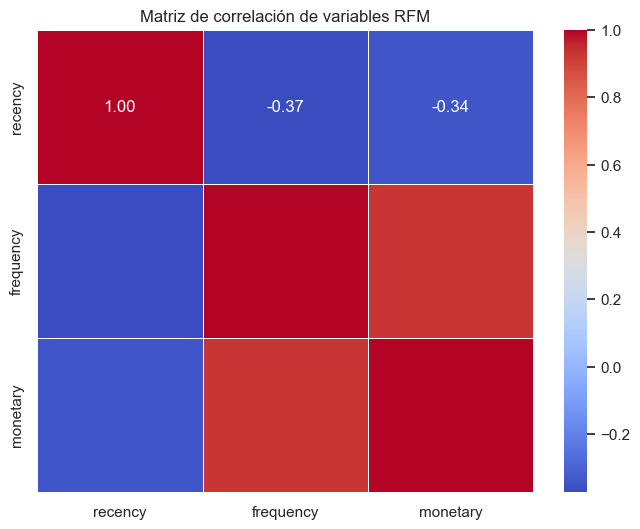

In [12]:
# Matriz de correlación de variables RFM 

# Seleccionar variables RFM
rfm_corr_vars = ["recency", "frequency", "monetary"]

# Calcular matriz de correlación
rfm_corr = customer_features[rfm_corr_vars].corr()

# Mostrar tabla de correlación
display(rfm_corr)

# Graficar matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(
    rfm_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación de variables RFM")
plt.show()

La matriz de correlación muestra que `recency` presenta una relación negativa con `frequency` y `monetary`. Esto es coherente con la lógica del modelo RFM, ya que clientes cuya última compra fue más reciente tienden a presentar mayor frecuencia de compra y mayor gasto acumulado.

A pesar de la relación entre algunas variables, se mantienen `recency`, `frequency` y `monetary`, ya que cada una aporta una dimensión distinta para la segmentación de clientes.

## Determinación del número óptimo de segmentos RFM

En esta sección se evalúa el número óptimo de segmentos para el modelo RFM. Para ello, se utilizan las variables `recency`, `frequency` y `monetary`, previamente estandarizadas para evitar que las diferencias de escala afecten el modelo.

Se aplican dos criterios de evaluación: el método del codo, basado en la inercia, y el coeficiente de Silhouette, que permite analizar la separación entre segmentos.

In [13]:
#Determinación del número óptimo de segmentos RFM

# Seleccionar variables RFM
rfm_vars = ["recency", "frequency", "monetary"]

X_rfm = customer_features[rfm_vars]

# Estandarizar variables RFM
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

# Probar distintos números de segmentos
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_rfm_scaled)
    
    inertias.append(kmeans.inertia_)
    
    # Se usa una muestra para que el cálculo de Silhouette sea más rápido
    score = silhouette_score(
        X_rfm_scaled, 
        labels, 
        sample_size=min(5000, X_rfm_scaled.shape[0]), 
        random_state=42
    )
    
    silhouette_scores.append(score)

# Crear tabla resumen de evaluación
evaluacion_rfm = pd.DataFrame({
    "Número de segmentos (K)": list(k_values),
    "Inercia": inertias,
    "Silhouette Score": silhouette_scores
})

display(evaluacion_rfm)

,Número de segmentos (K),Inercia,Silhouette Score
0,2,24866.543920,0.387867
1,3,16807.036525,0.386874
2,4,12881.088012,0.342143
3,5,10739.642940,0.347905
4,6,9089.922235,0.322508
5,7,7988.906471,0.318685
6,8,7184.692935,0.299586
7,9,6531.303877,0.303565
8,10,5907.218584,0.312794


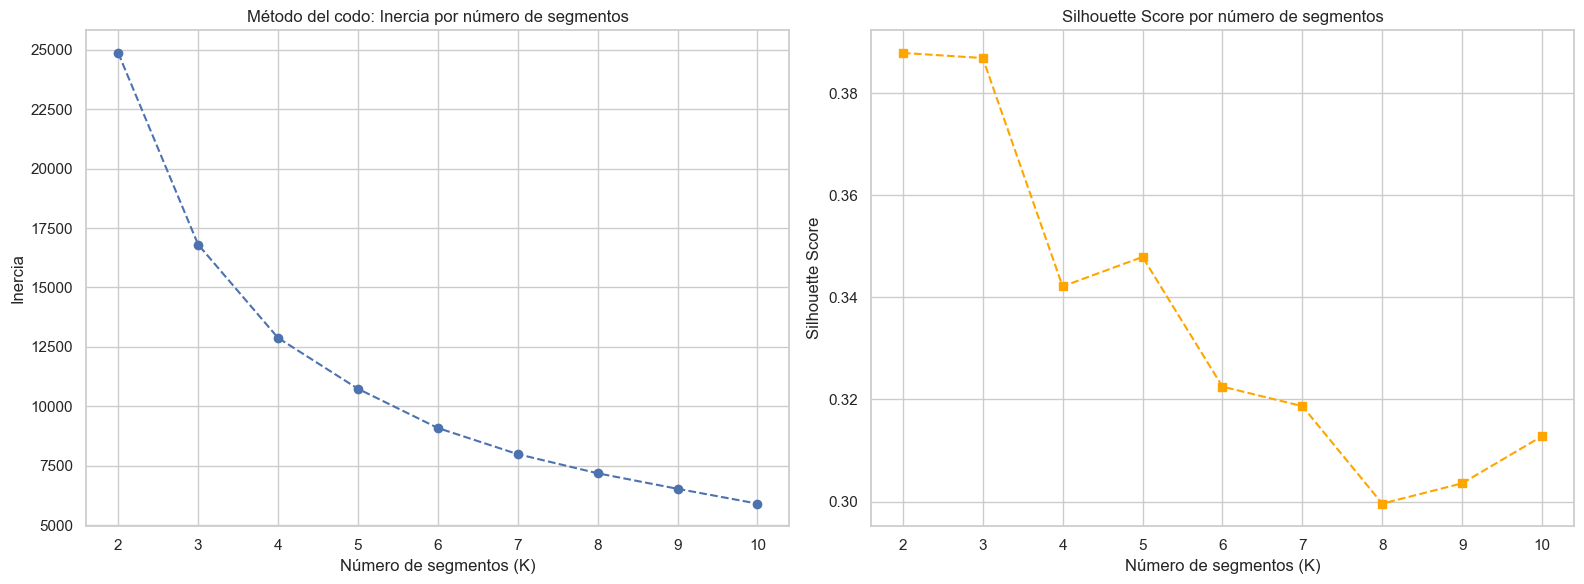

In [14]:
# Gráficos de evaluación 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Método del codo
axes[0].plot(
    evaluacion_rfm["Número de segmentos (K)"],
    evaluacion_rfm["Inercia"],
    marker="o",
    linestyle="--"
)

axes[0].set_title("Método del codo: Inercia por número de segmentos")
axes[0].set_xlabel("Número de segmentos (K)")
axes[0].set_ylabel("Inercia")
axes[0].grid(True)

# Gráfico 2: Silhouette Score
axes[1].plot(
    evaluacion_rfm["Número de segmentos (K)"],
    evaluacion_rfm["Silhouette Score"],
    marker="s",
    linestyle="--",
    color="orange"
)

axes[1].set_title("Silhouette Score por número de segmentos")
axes[1].set_xlabel("Número de segmentos (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
#Identificación del mejor K según Silhouette

mejor_k_silhouette = evaluacion_rfm.loc[
    evaluacion_rfm["Silhouette Score"].idxmax(), 
    "Número de segmentos (K)"
]

mejor_score = evaluacion_rfm["Silhouette Score"].max()

print(f"El mejor número de segmentos según Silhouette Score es: {mejor_k_silhouette}")
print(f"Silhouette Score obtenido: {mejor_score:.4f}")

El mejor número de segmentos según Silhouette Score es: 2
Silhouette Score obtenido: 0.3879


A partir de los resultados, se observa que el coeficiente de Silhouette presenta su mayor valor en K = 2. Sin embargo, se selecciona K = 3 para el modelo RFM, ya que permite una interpretación comercial más útil al diferenciar clientes de alto valor, valor medio y baja actividad.

Esta decisión busca equilibrar la calidad estadística del modelo con la utilidad estratégica de la segmentación para la toma de decisiones de marketing.

## Segmentación RFM mediante K-Means

En esta sección se aplica el modelo K-Means sobre las variables RFM estandarizadas. El objetivo es clasificar a los clientes según su comportamiento de compra, considerando recencia, frecuencia y valor monetarielo.

In [16]:
# Segmentación RFM mediante K-MEANS

# Selección del número final de segmentos RFM
k_rfm = 3 #seleccionado de forma empírica

# Ajustar modelo K-Means final
kmeans_rfm = KMeans(n_clusters=k_rfm, random_state=42, n_init=10)
customer_features["segmento_rfm"] = kmeans_rfm.fit_predict(X_rfm_scaled)

print("Modelo K-Means RFM ajustado correctamente")
print(f"Número de segmentos seleccionados: {k_rfm}")

# Revisar distribución de clientes por segmento
distribucion_rfm = customer_features["segmento_rfm"].value_counts().sort_index().reset_index()
distribucion_rfm.columns = ["Segmento RFM", "Cantidad de clientes"]

display(distribucion_rfm)

Modelo K-Means RFM ajustado correctamente
Número de segmentos seleccionados: 3


,Segmento RFM,Cantidad de clientes
0,0,7399
1,1,2336
2,2,5253


In [17]:
# Caracterización estadística de segmentos RFM

resumen_rfm = customer_features.groupby("segmento_rfm").agg(
    clientes=("customer_id", "count"),
    recency_promedio=("recency", "mean"),
    frequency_promedio=("frequency", "mean"),
    monetary_promedio=("monetary", "mean"),
    ticket_promedio=("avg_ticket", "mean"),
    satisfaccion_promedio=("avg_satisfaction", "mean"),
    tasa_pedido_anticipado=("order_ahead_rate", "mean"),
    tasa_pedido_con_comida=("food_order_rate", "mean")
).reset_index()

# Redondear valores numéricos
resumen_rfm = resumen_rfm.round(2)

display(resumen_rfm)

,segmento_rfm,clientes,recency_promedio,frequency_promedio,monetary_promedio,ticket_promedio,satisfaccion_promedio,tasa_pedido_anticipado,tasa_pedido_con_comida
0,0,7399,76.15,5.52,80.27,14.63,3.69,0.29,0.31
1,1,2336,297.25,4.17,61.16,14.74,3.70,0.29,0.30
2,2,5253,70.39,9.40,142.76,15.27,3.69,0.32,0.32


In [18]:
# Ordenamiento de segmentos RFM según valor comercial 
# Diccionario con nombres definidos por el grupo
nombres_segmentos_rfm = {
    2: "Clientes de alto valor",
    0: "Clientes de valor medio",
    1: "Clientes de baja actividad"
}

# Agregar nombre comercial a cada segmento
resumen_rfm["nombre_segmento_rfm"] = resumen_rfm["segmento_rfm"].map(nombres_segmentos_rfm)

# Ordenar segmentos según valor comercial
resumen_rfm_ordenado = resumen_rfm.sort_values(
    by=["monetary_promedio", "frequency_promedio"],
    ascending=False
)

display(resumen_rfm_ordenado)

,segmento_rfm,clientes,recency_promedio,frequency_promedio,monetary_promedio,ticket_promedio,satisfaccion_promedio,tasa_pedido_anticipado,tasa_pedido_con_comida,nombre_segmento_rfm
2,2,5253,70.39,9.40,142.76,15.27,3.69,0.32,0.32,Clientes de alto valor
0,0,7399,76.15,5.52,80.27,14.63,3.69,0.29,0.31,Clientes de valor medio
1,1,2336,297.25,4.17,61.16,14.74,3.70,0.29,0.30,Clientes de baja actividad


La segmentación RFM permite identificar tres grupos de clientes. El segmento de alto valor presenta mayor frecuencia de compra, mayor gasto promedio y menor recencia, lo que indica una relación más activa y valiosa con la empresa.

El segmento de valor medio presenta un comportamiento intermedio, mientras que el segmento de baja actividad se caracteriza por una mayor cantidad de días desde la última compra, menor frecuencia y menor gasto promedio.

In [19]:
# Interpretación resumida de segmentos RFM 

print("PERFILES DE SEGMENTOS RFM K-MEANS")
display(resumen_rfm_ordenado)

print("\nInterpretación técnica de segmentos RFM:")

total_clientes_rfm = resumen_rfm["clientes"].sum()

# Diccionario con nombres definidos por el grupo
nombres_segmentos_rfm = {
    2: "Clientes de alto valor",
    0: "Clientes de valor medio",
    1: "Clientes de baja actividad"
}

for _, row in resumen_rfm_ordenado.iterrows():
    
    segmento = int(row["segmento_rfm"])
    clientes = int(row["clientes"])
    porcentaje = clientes / total_clientes_rfm * 100
    
    nombre_segmento = nombres_segmentos_rfm.get(segmento, "Nombre por definir")
    
    print(f"\nSegmento {segmento}: {nombre_segmento}")
    print(f" - Clientes: {clientes:,} ({porcentaje:.1f}%)")
    print(f" - Recency promedio: {row['recency_promedio']:.2f} días")
    print(f" - Frequency promedio: {row['frequency_promedio']:.2f} compras")
    print(f" - Monetary promedio: ${row['monetary_promedio']:.2f}")
    print(f" - Ticket promedio: ${row['ticket_promedio']:.2f}")
    print(f" - Satisfacción promedio: {row['satisfaccion_promedio']:.2f}")
    print(f" - Tasa de pedido anticipado: {row['tasa_pedido_anticipado']:.2f}")
    print(f" - Tasa de pedido con comida: {row['tasa_pedido_con_comida']:.2f}")

PERFILES DE SEGMENTOS RFM K-MEANS


,segmento_rfm,clientes,recency_promedio,frequency_promedio,monetary_promedio,ticket_promedio,satisfaccion_promedio,tasa_pedido_anticipado,tasa_pedido_con_comida,nombre_segmento_rfm
2,2,5253,70.39,9.40,142.76,15.27,3.69,0.32,0.32,Clientes de alto valor
0,0,7399,76.15,5.52,80.27,14.63,3.69,0.29,0.31,Clientes de valor medio
1,1,2336,297.25,4.17,61.16,14.74,3.70,0.29,0.30,Clientes de baja actividad



Interpretación técnica de segmentos RFM:

Segmento 2: Clientes de alto valor
 - Clientes: 5,253 (35.0%)
 - Recency promedio: 70.39 días
 - Frequency promedio: 9.40 compras
 - Monetary promedio: $142.76
 - Ticket promedio: $15.27
 - Satisfacción promedio: 3.69
 - Tasa de pedido anticipado: 0.32
 - Tasa de pedido con comida: 0.32

Segmento 0: Clientes de valor medio
 - Clientes: 7,399 (49.4%)
 - Recency promedio: 76.15 días
 - Frequency promedio: 5.52 compras
 - Monetary promedio: $80.27
 - Ticket promedio: $14.63
 - Satisfacción promedio: 3.69
 - Tasa de pedido anticipado: 0.29
 - Tasa de pedido con comida: 0.31

Segmento 1: Clientes de baja actividad
 - Clientes: 2,336 (15.6%)
 - Recency promedio: 297.25 días
 - Frequency promedio: 4.17 compras
 - Monetary promedio: $61.16
 - Ticket promedio: $14.74
 - Satisfacción promedio: 3.70
 - Tasa de pedido anticipado: 0.29
 - Tasa de pedido con comida: 0.30


| Segmento RFM | Interpretación técnica | Nombre definido por el grupo |
|---|---|---|
| 2 | Mayor frecuencia, mayor gasto y menor recencia | Clientes de alto valor |
| 0 | Comportamiento intermedio | Clientes de valor medio |
| 1 | Menor actividad y mayor recencia | Clientes de baja actividad |

### Visualización de segmentos RFM mediante PCA

Para visualizar los segmentos RFM, se utiliza PCA, una técnica que reduce las variables originales a dos componentes principales. Esto permite representar gráficamente los clientes en un espacio bidimensional.

Cada punto representa un cliente y cada color corresponde a un segmento RFM. Las estrellas representan los centroides de cada grupo.

Varianza explicada por PC1: 71.65%
Varianza explicada por PC2: 25.96%
Varianza explicada acumulada: 97.61%


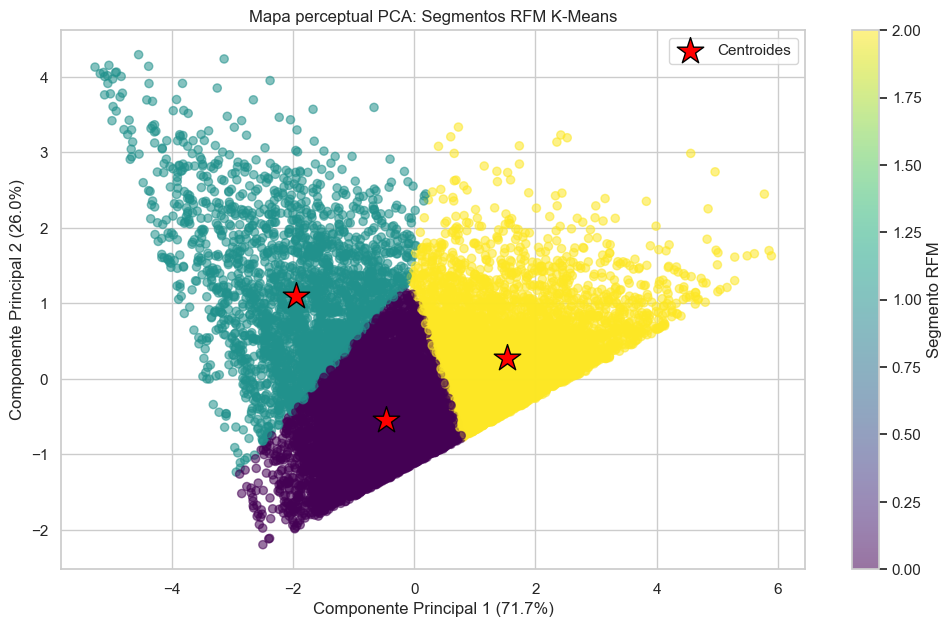

In [20]:
# Visualización de segmentos RFM mediante PCA 

# Reducir dimensionalidad a 2 componentes principales
pca_rfm = PCA(n_components=2)
X_rfm_pca = pca_rfm.fit_transform(X_rfm_scaled)

# Transformar los centroides al espacio PCA
centroides_pca = pca_rfm.transform(kmeans_rfm.cluster_centers_)

# Crear DataFrame para graficar
pca_df = pd.DataFrame({
    "PC1": X_rfm_pca[:, 0],
    "PC2": X_rfm_pca[:, 1],
    "segmento_rfm": customer_features["segmento_rfm"]
})

# Varianza explicada por cada componente
varianza_pc1 = pca_rfm.explained_variance_ratio_[0] * 100
varianza_pc2 = pca_rfm.explained_variance_ratio_[1] * 100
varianza_total = pca_rfm.explained_variance_ratio_.sum() * 100

print(f"Varianza explicada por PC1: {varianza_pc1:.2f}%")
print(f"Varianza explicada por PC2: {varianza_pc2:.2f}%")
print(f"Varianza explicada acumulada: {varianza_total:.2f}%")

# Gráfico PCA
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["segmento_rfm"],
    cmap="viridis",
    alpha=0.55,
    s=35
)

# Graficar centroides
plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="*",
    s=400,
    edgecolor="black",
    label="Centroides"
)

plt.title("Mapa perceptual PCA: Segmentos RFM K-Means")
plt.xlabel(f"Componente Principal 1 ({varianza_pc1:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({varianza_pc2:.1f}%)")
plt.colorbar(scatter, label="Segmento RFM")
plt.legend()
plt.grid(True)
plt.show()

El mapa PCA muestra una separación visual clara entre los segmentos RFM. Esto se debe a que el modelo utiliza tres variables numéricas directamente relacionadas con el comportamiento de compra y las dos primeras componentes principales explican una alta proporción de la variabilidad total.s.

## Segmentación socio-demográfica

En esta sección se construye un segundo modelo de segmentación utilizando variables socio-demográficas y de comportamiento. A diferencia del modelo RFM, este enfoque no se centra directamente en el valor monetario o la frecuencia de compra, sino en el perfil del cliente, su canal de consumo, ubicación, preferencias y experiencia de compra.

Este modelo permite complementar el análisis RFM, entregando información útil sobre quiénes son los clientes y cómo consumen.

### Justificación de variables seleccionadas

Las variables seleccionadas para la segmentación socio-demográfica consideran distintas dimensiones del comportamiento del cliente: ubicación, tipo de tienda, canal de compra, grupo etario, género, membresía Rewards, categoría principal de bebida y horario de consumo.

También se incluyen variables numéricas asociadas al comportamiento de compra, como ticket promedio, tamaño del carrito, personalizaciones, satisfacción, pedidos anticipados y pedidos con comida. Estas variables permiten describir con mayor profundidad los perfiles de clientes sin repetir directamente las variables centrales del modelo RFM.

In [21]:
#Selección de variables socio-demográficas 

# Variables categóricas para segmentación socio-demográfica
socio_cat_vars = [
    "main_region",
    "main_store_location_type",
    "main_order_channel",
    "main_age_group",
    "main_gender",
    "rewards_member",
    "main_drink_category",
    "main_time_slot"
]

# Variables numéricas complementarias
socio_num_vars = [
    "avg_ticket",
    "avg_cart_size",
    "avg_customizations",
    "avg_satisfaction",
    "order_ahead_rate",
    "food_order_rate"
]

# Base para el modelo socio-demográfico
X_socio = customer_features[socio_cat_vars + socio_num_vars]

print("Variables seleccionadas para segmentación socio-demográfica:")
print(X_socio.columns.tolist())

display(X_socio.head())

Variables seleccionadas para segmentación socio-demográfica:
['main_region', 'main_store_location_type', 'main_order_channel', 'main_age_group', 'main_gender', 'rewards_member', 'main_drink_category', 'main_time_slot', 'avg_ticket', 'avg_cart_size', 'avg_customizations', 'avg_satisfaction', 'order_ahead_rate', 'food_order_rate']


,main_region,main_store_location_type,main_order_channel,main_age_group,main_gender,rewards_member,main_drink_category,main_time_slot,avg_ticket,avg_cart_size,avg_customizations,avg_satisfaction,order_ahead_rate,food_order_rate
0,Midwest,Suburban,Drive-Thru,35-44,Male,False,Brewed Coffee,Tarde,14.550000,3.666667,2.500000,3.250000,0.250000,0.250000
1,Southwest,Urban,Mobile App,25-34,Male,False,Refresher,Tarde,15.936923,4.076923,2.076923,4.076923,0.384615,0.461538
2,Midwest,Suburban,Mobile App,35-44,Female,False,Espresso,Tarde,15.942000,4.200000,1.200000,3.400000,0.400000,0.200000
3,Southwest,Suburban,Drive-Thru,45-54,Male,False,Other,Mañana,13.692857,3.571429,2.000000,4.142857,0.142857,0.428571
4,Midwest,Suburban,Drive-Thru,25-34,Male,False,Espresso,Mañana,15.816667,4.666667,1.333333,3.666667,0.000000,0.333333


In [22]:
#Procesamiento  de variables socio-demográficas

# Transformador para variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Transformador para variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Preprocesador general
preprocessor_socio = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, socio_num_vars),
        ("cat", categorical_transformer, socio_cat_vars)
    ]
)

# Aplicar transformación
X_socio_processed = preprocessor_socio.fit_transform(X_socio)

print("Preprocesamiento socio-demográfico realizado correctamente")
print(f"Dimensión final de la matriz procesada: {X_socio_processed.shape}")

Preprocesamiento socio-demográfico realizado correctamente
Dimensión final de la matriz procesada: (14988, 39)


### Evaluación del número óptimo de segmentos socio-demográficos

En esta sección se evalúan distintos valores de K para el modelo socio-demográfico. Debido a que este modelo incluye variables categóricas transformadas mediante One-Hot Encoding y variables numéricas estandarizadas, los segmentos pueden presentar menor separación que en el modelo RFM.

Se utiliza el método del codo y el coeficiente de Silhouette para seleccionar el número de segmentos más adecuado.

In [23]:
# Determinación del número óptimo de segmentos socio-demográficos

k_values_socio = range(2, 11)

inertias_socio = []
silhouette_scores_socio = []

for k in k_values_socio:
    kmeans_socio_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_socio_temp = kmeans_socio_temp.fit_predict(X_socio_processed)
    
    inertias_socio.append(kmeans_socio_temp.inertia_)
    
    score_socio = silhouette_score(
        X_socio_processed,
        labels_socio_temp,
        sample_size=min(5000, X_socio_processed.shape[0]),
        random_state=42
    )
    
    silhouette_scores_socio.append(score_socio)

evaluacion_socio = pd.DataFrame({
    "Número de segmentos (K)": list(k_values_socio),
    "Inercia": inertias_socio,
    "Silhouette Score": silhouette_scores_socio
})

display(evaluacion_socio)

,Número de segmentos (K),Inercia,Silhouette Score
0,2,143585.059260,0.131543
1,3,136544.022869,0.084448
2,4,130628.741288,0.071836
3,5,126881.706103,0.068112
4,6,123699.694999,0.061396
5,7,121518.582769,0.057163
6,8,119457.842906,0.054791
7,9,117679.009777,0.054167
8,10,116094.292993,0.051261


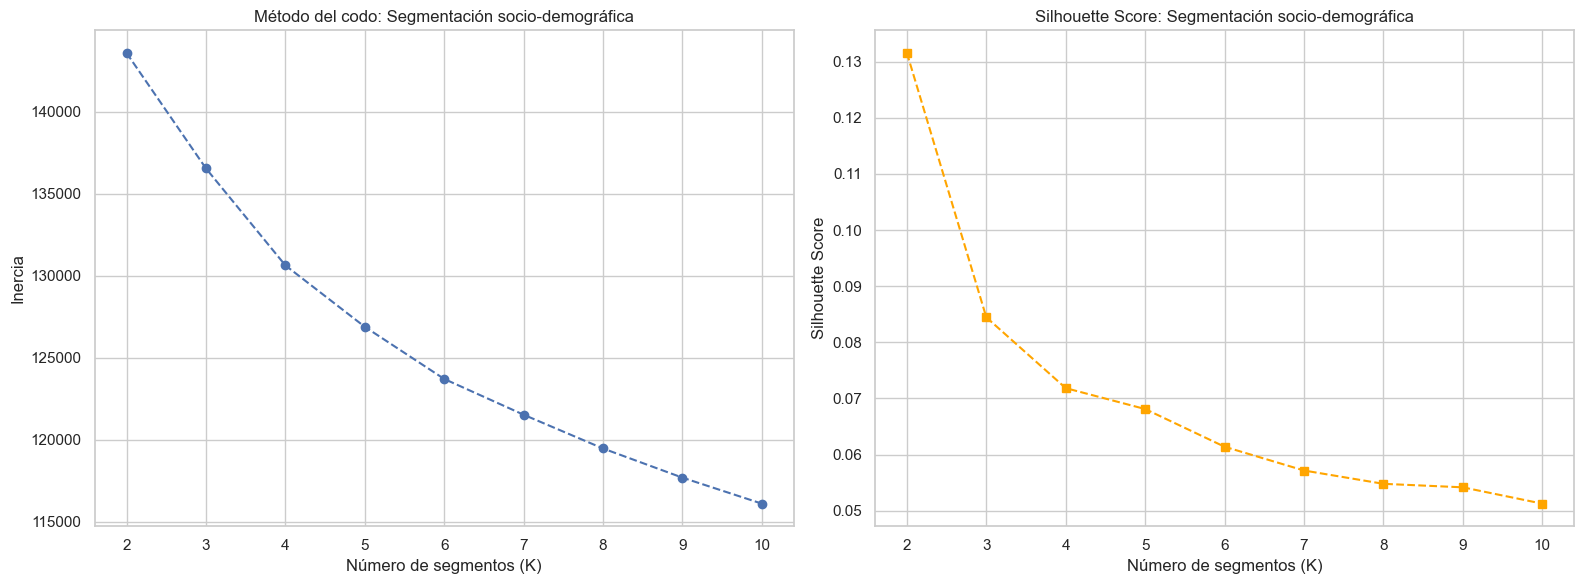

In [24]:
# Gráficos de evaluación del modelo socio-demográfico 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Método del codo
axes[0].plot(
    evaluacion_socio["Número de segmentos (K)"],
    evaluacion_socio["Inercia"],
    marker="o",
    linestyle="--"
)

axes[0].set_title("Método del codo: Segmentación socio-demográfica")
axes[0].set_xlabel("Número de segmentos (K)")
axes[0].set_ylabel("Inercia")
axes[0].grid(True)

# Silhouette Score
axes[1].plot(
    evaluacion_socio["Número de segmentos (K)"],
    evaluacion_socio["Silhouette Score"],
    marker="s",
    linestyle="--",
    color="orange"
)

axes[1].set_title("Silhouette Score: Segmentación socio-demográfica")
axes[1].set_xlabel("Número de segmentos (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()
plt.show()

De acuerdo con los resultados, se selecciona K = 2 para la segmentación socio-demográfica, ya que este valor presenta el mayor Silhouette Score entre las alternativas evaluadas.

Aunque un mayor número de segmentos podría entregar una lectura más detallada, los resultados muestran que la separación entre grupos disminuye al aumentar K. Por lo tanto, K = 2 entrega el mejor equilibrio estadístico para este modelo.

## Segmentación socio-demográfica mediante K-Means

En esta sección se aplica el modelo K-Means al conjunto de variables socio-demográficas y de comportamiento. A partir de la evaluación realizada, se selecciona K = 2 como número final de segmentos.


In [25]:
# Segmentación socio-demográfica mediante K-Means
# Selección del número final de segmentos socio-demográficos
k_socio = 2

# Ajustar modelo K-Means final
kmeans_socio = KMeans(n_clusters=k_socio, random_state=42, n_init=10)
customer_features["segmento_socio"] = kmeans_socio.fit_predict(X_socio_processed)

print("Modelo K-Means socio-demográfico ajustado correctamente")
print(f"Número de segmentos seleccionados: {k_socio}")

# Distribución de clientes por segmento
distribucion_socio = customer_features["segmento_socio"].value_counts().sort_index().reset_index()
distribucion_socio.columns = ["Segmento socio-demográfico", "Cantidad de clientes"]

# Calcular porcentaje
distribucion_socio["Porcentaje"] = (
    distribucion_socio["Cantidad de clientes"] / distribucion_socio["Cantidad de clientes"].sum() * 100
).round(2)

display(distribucion_socio)

Modelo K-Means socio-demográfico ajustado correctamente
Número de segmentos seleccionados: 2


,Segmento socio-demográfico,Cantidad de clientes,Porcentaje
0,0,7022,46.85
1,1,7966,53.15


In [26]:
#Caracterización numérica de segmentos socio-demográficos 

resumen_socio_num = customer_features.groupby("segmento_socio").agg(
    clientes=("customer_id", "count"),
    ticket_promedio=("avg_ticket", "mean"),
    carrito_promedio=("avg_cart_size", "mean"),
    personalizaciones_promedio=("avg_customizations", "mean"),
    satisfaccion_promedio=("avg_satisfaction", "mean"),
    tasa_pedido_anticipado=("order_ahead_rate", "mean"),
    tasa_pedido_con_comida=("food_order_rate", "mean")
).reset_index()

resumen_socio_num = resumen_socio_num.round(2)

display(resumen_socio_num)

,segmento_socio,clientes,ticket_promedio,carrito_promedio,personalizaciones_promedio,satisfaccion_promedio,tasa_pedido_anticipado,tasa_pedido_con_comida
0,0,7022,16.73,4.15,2.15,3.77,0.44,0.36
1,1,7966,13.24,3.39,1.53,3.62,0.18,0.27


In [27]:
# Caracterización categórica de segmentos socio-demográficos

resumen_categorico_socio = []

for segmento in sorted(customer_features["segmento_socio"].unique()):
    df_seg = customer_features[customer_features["segmento_socio"] == segmento]
    
    for col in socio_cat_vars:
        categoria_principal = df_seg[col].mode()[0]
        porcentaje_categoria = (
            df_seg[col].value_counts(normalize=True).iloc[0] * 100
        )
        
        resumen_categorico_socio.append({
            "segmento_socio": segmento,
            "variable": col,
            "categoria_principal": categoria_principal,
            "porcentaje_categoria_principal": round(porcentaje_categoria, 2)
        })

resumen_categorico_socio = pd.DataFrame(resumen_categorico_socio)

display(resumen_categorico_socio)

,segmento_socio,variable,categoria_principal,porcentaje_categoria_principal
0,0,main_region,Midwest,27.93
1,0,main_store_location_type,Rural,39.39
2,0,main_order_channel,Mobile App,81.61
3,0,main_age_group,25-34,41.63
4,0,main_gender,Female,46.28
5,0,rewards_member,True,50.30
6,0,main_drink_category,Brewed Coffee,26.12
7,0,main_time_slot,Mañana,61.96
8,1,main_region,Midwest,29.89
9,1,main_store_location_type,Rural,39.67


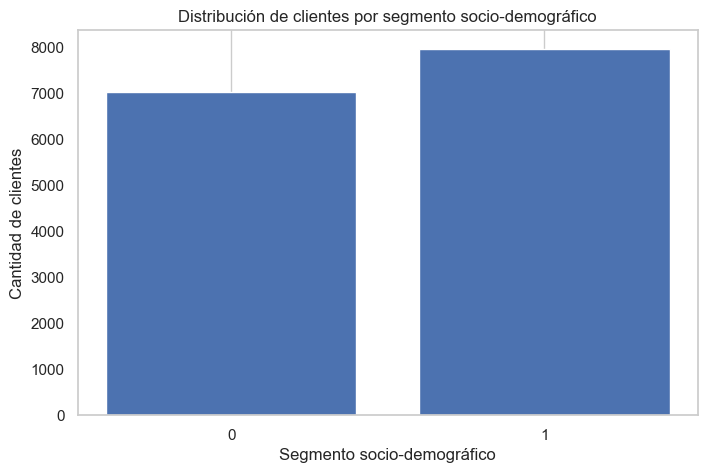

In [28]:
# Gráfico de distribución de segmentos socio-demográficos 

plt.figure(figsize=(8, 5))

plt.bar(
    distribucion_socio["Segmento socio-demográfico"].astype(str),
    distribucion_socio["Cantidad de clientes"]
)

plt.title("Distribución de clientes por segmento socio-demográfico")
plt.xlabel("Segmento socio-demográfico")
plt.ylabel("Cantidad de clientes")
plt.grid(axis="y")
plt.show()

In [29]:
# Interpretación resumida de segmentos socio-demográficos 

print("PERFILES DE SEGMENTOS SOCIO-DEMOGRÁFICOS K-MEANS")

display(resumen_socio_num)

print("\nInterpretación técnica de segmentos socio-demográficos:")

total_clientes_socio = resumen_socio_num["clientes"].sum()

nombres_segmentos_socio = {
    0: "Clientes digitales de consumo ampliado",
    1: "Clientes tradicionales de compra rápida"
}

for _, row in resumen_socio_num.iterrows():
    
    segmento = int(row["segmento_socio"])
    clientes = int(row["clientes"])
    porcentaje = clientes / total_clientes_socio * 100
    
    nombre_segmento = nombres_segmentos_socio.get(segmento, "Nombre por definir")
    
    print(f"\nSegmento {segmento}: {nombre_segmento}")
    print(f" - Clientes: {clientes:,} ({porcentaje:.1f}%)")
    print(f" - Ticket promedio: ${row['ticket_promedio']:.2f}")
    print(f" - Carrito promedio: {row['carrito_promedio']:.2f} productos")
    print(f" - Personalizaciones promedio: {row['personalizaciones_promedio']:.2f}")
    print(f" - Satisfacción promedio: {row['satisfaccion_promedio']:.2f}")
    print(f" - Tasa de pedido anticipado: {row['tasa_pedido_anticipado']:.2f}")
    print(f" - Tasa de pedido con comida: {row['tasa_pedido_con_comida']:.2f}")
    
    print(" - Categorías principales:")
    
    categorias_segmento = resumen_categorico_socio[
        resumen_categorico_socio["segmento_socio"] == segmento
    ]
    
    for _, cat_row in categorias_segmento.iterrows():
        print(
            f"   • {cat_row['variable']}: "
            f"{cat_row['categoria_principal']} "
            f"({cat_row['porcentaje_categoria_principal']:.1f}%)"
        )

PERFILES DE SEGMENTOS SOCIO-DEMOGRÁFICOS K-MEANS


,segmento_socio,clientes,ticket_promedio,carrito_promedio,personalizaciones_promedio,satisfaccion_promedio,tasa_pedido_anticipado,tasa_pedido_con_comida
0,0,7022,16.73,4.15,2.15,3.77,0.44,0.36
1,1,7966,13.24,3.39,1.53,3.62,0.18,0.27



Interpretación técnica de segmentos socio-demográficos:

Segmento 0: Clientes digitales de consumo ampliado
 - Clientes: 7,022 (46.9%)
 - Ticket promedio: $16.73
 - Carrito promedio: 4.15 productos
 - Personalizaciones promedio: 2.15
 - Satisfacción promedio: 3.77
 - Tasa de pedido anticipado: 0.44
 - Tasa de pedido con comida: 0.36
 - Categorías principales:
   • main_region: Midwest (27.9%)
   • main_store_location_type: Rural (39.4%)
   • main_order_channel: Mobile App (81.6%)
   • main_age_group: 25-34 (41.6%)
   • main_gender: Female (46.3%)
   • rewards_member: True (50.3%)
   • main_drink_category: Brewed Coffee (26.1%)
   • main_time_slot: Mañana (62.0%)

Segmento 1: Clientes tradicionales de compra rápida
 - Clientes: 7,966 (53.1%)
 - Ticket promedio: $13.24
 - Carrito promedio: 3.39 productos
 - Personalizaciones promedio: 1.53
 - Satisfacción promedio: 3.62
 - Tasa de pedido anticipado: 0.18
 - Tasa de pedido con comida: 0.27
 - Categorías principales:
   • main_region: Mid

El segmento 0 se caracteriza por un mayor ticket promedio, mayor carrito, más personalizaciones, mayor satisfacción, mayor uso de pedidos anticipados y mayor proporción de pedidos con comida. Además, presenta una fuerte asociación con el canal Mobile App y una mayor presencia de clientes Rewards.

El segmento 1 presenta un comportamiento más tradicional, con menor ticket promedio, menor carrito, menor personalización y mayor predominio del canal Drive-Thru. Por ello, se interpreta como un perfil de compra más rápida y menos digitalizada.

## Comparación entre modelos de segmentación

En esta sección se comparan los resultados obtenidos mediante el modelo RFM y el modelo socio-demográfico. El modelo RFM permite identificar clientes según su valor comercial y actividad de compra, mientras que el modelo socio-demográfico permite describir el perfil, canal y hábitos de consumo.

La comparación permite evaluar qué modelo entrega mayor utilidad para identificar mercados meta relevantes para Starbucks America.

In [30]:
# Comparación entre modelos de segmentación 

# Obtener el nombre correcto de la columna K en cada tabla
col_k_rfm = "Número de segmentos (K)" if "Número de segmentos (K)" in evaluacion_rfm.columns else "Número de segmentos"
col_k_socio = "Número de segmentos (K)" if "Número de segmentos (K)" in evaluacion_socio.columns else "Número de segmentos"

# Obtener Silhouette Score del K seleccionado en cada modelo
silhouette_rfm_final = evaluacion_rfm.loc[
    evaluacion_rfm[col_k_rfm] == k_rfm, 
    "Silhouette Score"
].values[0]

silhouette_socio_final = evaluacion_socio.loc[
    evaluacion_socio[col_k_socio] == k_socio, 
    "Silhouette Score"
].values[0]

# Crear tabla comparativa
comparacion_modelos = pd.DataFrame({
    "Modelo": ["RFM", "Socio-demográfico"],
    "Número de segmentos seleccionados": [k_rfm, k_socio],
    "Silhouette Score": [silhouette_rfm_final, silhouette_socio_final],
    "Variables principales": [
        "Recency, Frequency, Monetary",
        "Región, canal, edad, género, Rewards, categoría, horario y variables de consumo"
    ],
    "Enfoque del modelo": [
        "Comportamiento de compra y valor comercial",
        "Perfil del cliente, hábitos y forma de consumo"
    ]
})

display(comparacion_modelos)

,Modelo,Número de segmentos seleccionados,Silhouette Score,Variables principales,Enfoque del modelo
0,RFM,3,0.386874,"Recency, Frequency, Monetary",Comportamiento de compra y valor comercial
1,Socio-demográfico,2,0.131543,"Región, canal, edad, género, Rewards, categorí...","Perfil del cliente, hábitos y forma de consumo"


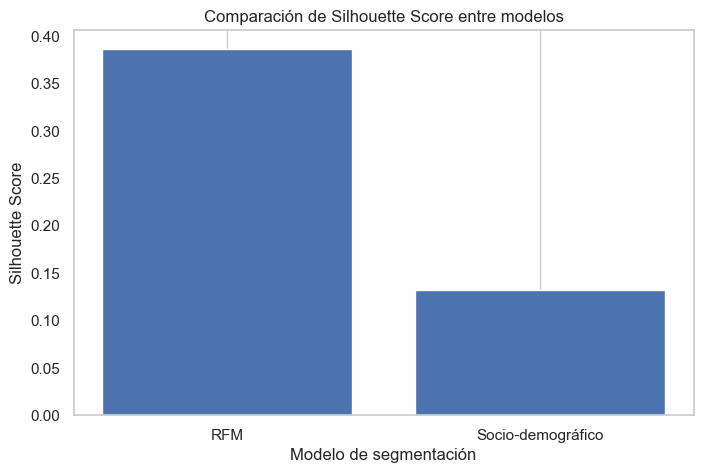

In [31]:
#Gráfico comparativo de calidad de modelos 

plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_modelos["Modelo"],
    comparacion_modelos["Silhouette Score"]
)

plt.title("Comparación de Silhouette Score entre modelos")
plt.xlabel("Modelo de segmentación")
plt.ylabel("Silhouette Score")
plt.grid(axis="y")
plt.show()

### Cruce entre segmentos RFM y socio-demográficos

En esta sección se cruzan los segmentos obtenidos en ambos modelos. El objetivo es analizar qué perfiles socio-demográficos predominan dentro de cada segmento RFM, especialmente dentro del grupo de clientes de alto valor.

Este cruce permite conectar el valor comercial del cliente con su perfil de consumo, lo que resulta relevante para la identificación de mercados meta.

In [32]:
# Cruce entre segmentos RFM y socio-demográfico
# Crear nombres comerciales para los segmentos RFM
nombres_segmentos_rfm = {
    2: "Clientes de alto valor",
    0: "Clientes de valor medio",
    1: "Clientes de baja actividad"
}

customer_features["nombre_segmento_rfm"] = customer_features["segmento_rfm"].map(nombres_segmentos_rfm)
cruce_segmentos = pd.crosstab(
    customer_features["nombre_segmento_rfm"],
    customer_features["segmento_socio"],
    margins=True
)

display(cruce_segmentos)

segmento_socio,0,1,All
nombre_segmento_rfm,,,
Clientes de alto valor,2826,2427,5253
Clientes de baja actividad,1006,1330,2336
Clientes de valor medio,3190,4209,7399
All,7022,7966,14988


In [33]:
# Cruce porcentual entre segmentos

cruce_segmentos_pct = pd.crosstab(
    customer_features["nombre_segmento_rfm"],
    customer_features["segmento_socio"],
    normalize="index"
) * 100

cruce_segmentos_pct = cruce_segmentos_pct.round(2)

display(cruce_segmentos_pct)

segmento_socio,0,1
nombre_segmento_rfm,,
Clientes de alto valor,53.80,46.20
Clientes de baja actividad,43.07,56.93
Clientes de valor medio,43.11,56.89


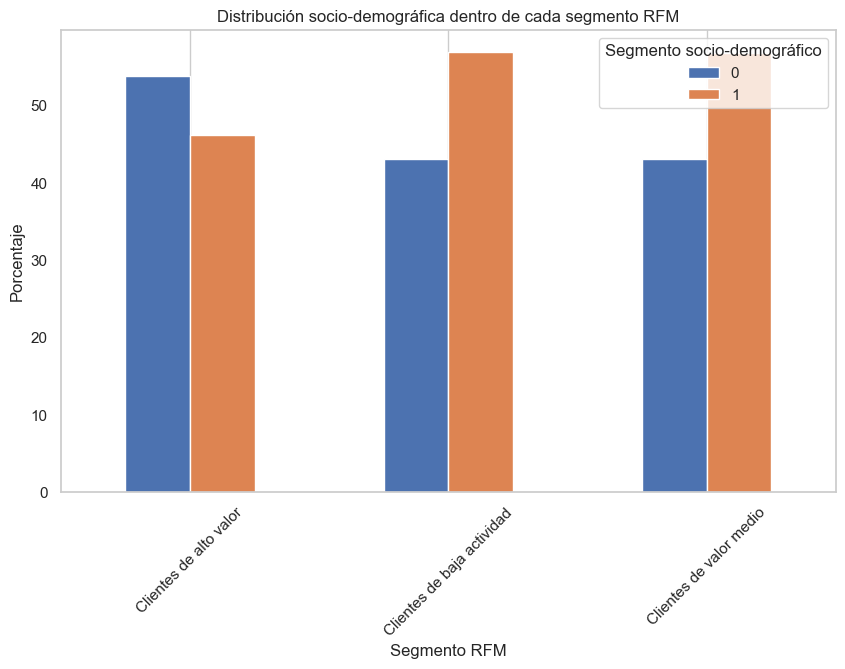

In [34]:
# Gráfico de cruce entre modelos 

cruce_segmentos_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribución socio-demográfica dentro de cada segmento RFM")
plt.xlabel("Segmento RFM")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45)
plt.legend(title="Segmento socio-demográfico")
plt.grid(axis="y")
plt.show()

El cruce entre modelos muestra que los clientes de alto valor RFM presentan mayor participación del segmento socio-demográfico 0. Esto indica que el perfil digital de consumo ampliado está más asociado a los clientes comercialmente más atractivos.

Por el contrario, los clientes de valor medio y baja actividad presentan mayor participación del segmento socio-demográfico 1, asociado a un perfil más tradicional y de compra rápida.

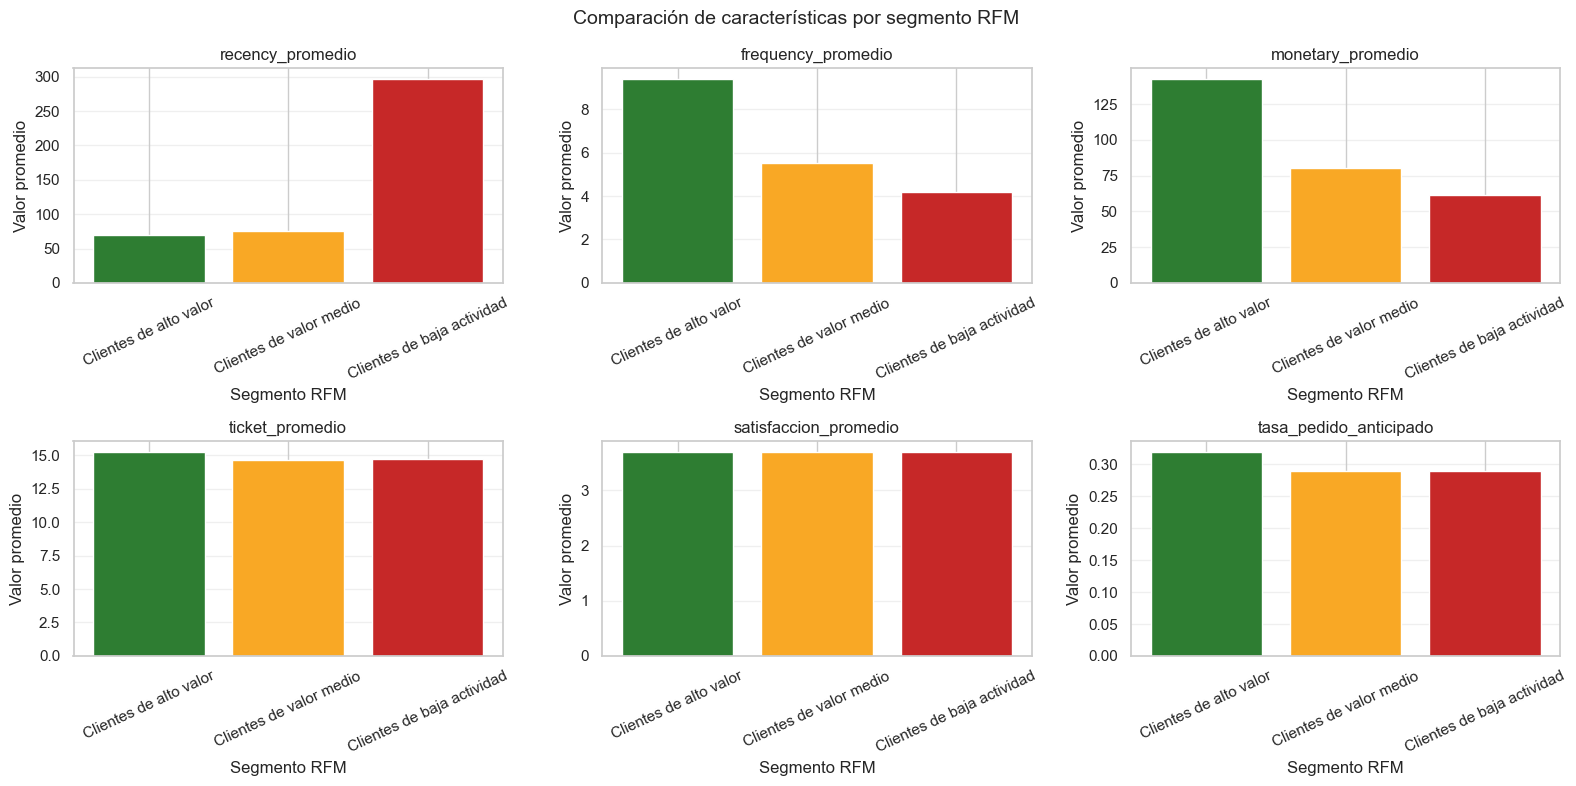

In [35]:
# Visualización de variables RFM 

resumen_rfm_plot = resumen_rfm_ordenado.copy()

variables_rfm_grafico = [
    "recency_promedio",
    "frequency_promedio",
    "monetary_promedio",
    "ticket_promedio",
    "satisfaccion_promedio",
    "tasa_pedido_anticipado"
]

# Colores para los segmentos
colores_segmentos = [
    "#2E7D32",  # verde
    "#F9A825",  # amarillo/dorado
    "#C62828"   # rojo
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, variable in enumerate(variables_rfm_grafico):
    axes[i].bar(
        resumen_rfm_plot["nombre_segmento_rfm"],
        resumen_rfm_plot[variable],
        color=colores_segmentos
    )
    
    axes[i].set_title(variable)
    axes[i].set_xlabel("Segmento RFM")
    axes[i].set_ylabel("Valor promedio")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Comparación de características por segmento RFM", fontsize=14)
plt.tight_layout()
plt.show()

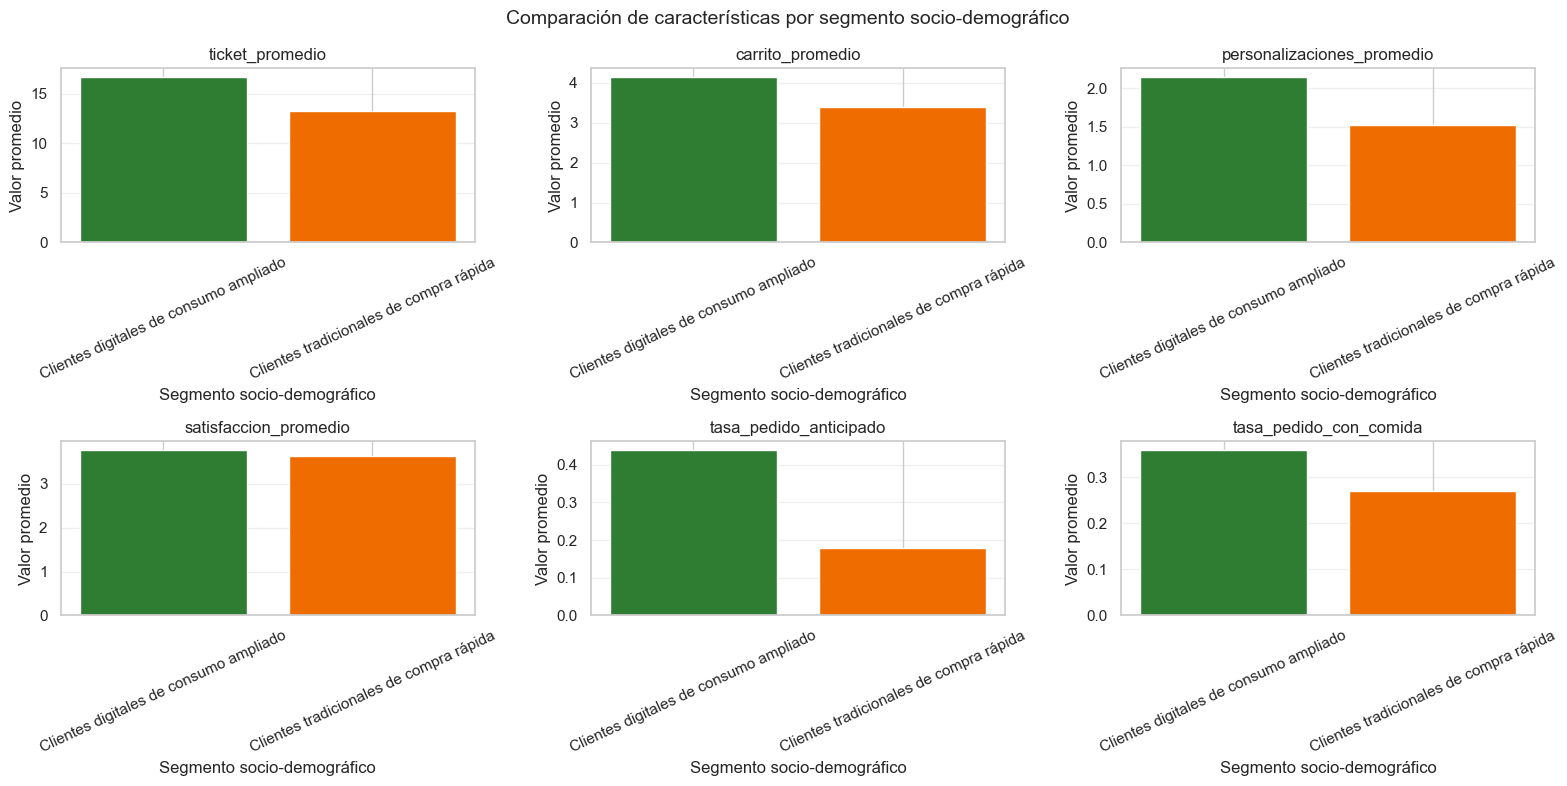

In [36]:
# Visualización de variables socio-demográficos

resumen_socio_plot = resumen_socio_num.copy()

resumen_socio_plot["nombre_segmento_socio"] = resumen_socio_plot["segmento_socio"].map(
    nombres_segmentos_socio
)

variables_socio_grafico = [
    "ticket_promedio",
    "carrito_promedio",
    "personalizaciones_promedio",
    "satisfaccion_promedio",
    "tasa_pedido_anticipado",
    "tasa_pedido_con_comida"
]

# Colores para los segmentos socio-demográficos
colores_socio = [
    "#2E7D32",  # verde: clientes digitales de consumo ampliado
    "#EF6C00"   # naranjo: clientes tradicionales de compra rápida
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, variable in enumerate(variables_socio_grafico):
    axes[i].bar(
        resumen_socio_plot["nombre_segmento_socio"],
        resumen_socio_plot[variable],
        color=colores_socio
    )
    
    axes[i].set_title(variable)
    axes[i].set_xlabel("Segmento socio-demográfico")
    axes[i].set_ylabel("Valor promedio")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Comparación de características por segmento socio-demográfico", fontsize=14)
plt.tight_layout()
plt.show()

## Identificación del mercado meta principal

En esta sección se identifica el mercado meta principal a partir del cruce entre la segmentación RFM y la segmentación socio-demográfica. Se considera como mercado meta principal a los clientes de alto valor RFM que pertenecen al segmento socio-demográfico 0.

Este grupo resulta relevante porque combina alto valor comercial con un perfil digital, mayor consumo por pedido, mayor uso de Mobile App, pedidos anticipados y mayor vínculo con Rewards.

In [37]:
# Identificación del mercado meta principal

# Crear nombres para segmentos socio-demográficos
nombres_segmentos_socio = {
    0: "Clientes digitales de consumo ampliado",
    1: "Clientes tradicionales de compra rápida"
}

customer_features["nombre_segmento_socio"] = customer_features["segmento_socio"].map(nombres_segmentos_socio)

# Definir mercado meta principal
customer_features["mercado_meta_principal"] = np.where(
    (customer_features["nombre_segmento_rfm"] == "Clientes de alto valor") &
    (customer_features["segmento_socio"] == 0),
    "Mercado meta principal",
    "Otros clientes"
)

# Distribución del mercado meta principal
distribucion_mercado_meta = customer_features["mercado_meta_principal"].value_counts().reset_index()
distribucion_mercado_meta.columns = ["Clasificación", "Cantidad de clientes"]

distribucion_mercado_meta["Porcentaje"] = (
    distribucion_mercado_meta["Cantidad de clientes"] / customer_features.shape[0] * 100
).round(2)

display(distribucion_mercado_meta)

,Clasificación,Cantidad de clientes,Porcentaje
0,Otros clientes,12162,81.14
1,Mercado meta principal,2826,18.86


In [38]:
# Caracterización del mercado meta principal 


mercado_meta = customer_features[
    customer_features["mercado_meta_principal"] == "Mercado meta principal"
]

print(f"Cantidad de clientes en el mercado meta principal: {mercado_meta.shape[0]}")

resumen_mercado_meta = pd.DataFrame({
    "Indicador": [
        "Clientes",
        "Recency promedio",
        "Frequency promedio",
        "Monetary promedio",
        "Ticket promedio",
        "Carrito promedio",
        "Personalizaciones promedio",
        "Satisfacción promedio",
        "Tasa pedido anticipado",
        "Tasa pedido con comida"
    ],
    "Valor": [
        mercado_meta["customer_id"].count(),
        mercado_meta["recency"].mean(),
        mercado_meta["frequency"].mean(),
        mercado_meta["monetary"].mean(),
        mercado_meta["avg_ticket"].mean(),
        mercado_meta["avg_cart_size"].mean(),
        mercado_meta["avg_customizations"].mean(),
        mercado_meta["avg_satisfaction"].mean(),
        mercado_meta["order_ahead_rate"].mean(),
        mercado_meta["food_order_rate"].mean()
    ]
})

resumen_mercado_meta["Valor"] = resumen_mercado_meta["Valor"].round(2)

display(resumen_mercado_meta)

Cantidad de clientes en el mercado meta principal: 2826


,Indicador,Valor
0,Clientes,2826.00
1,Recency promedio,72.13
2,Frequency promedio,9.18
3,Monetary promedio,151.53
4,Ticket promedio,16.59
5,Carrito promedio,4.13
6,Personalizaciones promedio,2.08
7,Satisfacción promedio,3.74
8,Tasa pedido anticipado,0.42
9,Tasa pedido con comida,0.36


In [39]:
# Perfil categórico del mercado meta principal 

perfil_categorico_mercado_meta = []

for col in socio_cat_vars:
    categoria_principal = mercado_meta[col].mode()[0]
    porcentaje_categoria = mercado_meta[col].value_counts(normalize=True).iloc[0] * 100
    
    perfil_categorico_mercado_meta.append({
        "Variable": col,
        "Categoría principal": categoria_principal,
        "Porcentaje": round(porcentaje_categoria, 2)
    })

perfil_categorico_mercado_meta = pd.DataFrame(perfil_categorico_mercado_meta)

display(perfil_categorico_mercado_meta)

,Variable,Categoría principal,Porcentaje
0,main_region,Midwest,25.83
1,main_store_location_type,Suburban,39.49
2,main_order_channel,Mobile App,87.47
3,main_age_group,25-34,42.71
4,main_gender,Female,46.46
5,rewards_member,True,50.53
6,main_drink_category,Brewed Coffee,24.42
7,main_time_slot,Mañana,63.13


El mercado meta principal se caracteriza por una alta presencia del canal Mobile App, consumo en horario de mañana, grupo etario predominante entre 25 y 34 años, y una mayor asociación con el programa Rewards.

Estos resultados sugieren que el mercado meta corresponde a clientes digitales, de consumo ampliado y con hábitos compatibles con estrategias de conveniencia, fidelización y promociones matutinas.

In [40]:
# Mercado meta por región y tipo de tienda 

mercado_meta_region_tienda = mercado_meta.groupby(
    ["main_region", "main_store_location_type"]
).agg(
    clientes=("customer_id", "count"),
    ticket_promedio=("avg_ticket", "mean"),
    monetary_promedio=("monetary", "mean"),
    satisfaccion_promedio=("avg_satisfaction", "mean")
).reset_index()

mercado_meta_region_tienda["Porcentaje_clientes"] = (
    mercado_meta_region_tienda["clientes"] / mercado_meta_region_tienda["clientes"].sum() * 100
).round(2)

mercado_meta_region_tienda = mercado_meta_region_tienda.sort_values(
    by=["clientes", "monetary_promedio"],
    ascending=False
).round(2)

display(mercado_meta_region_tienda)

,main_region,main_store_location_type,clientes,ticket_promedio,monetary_promedio,satisfaccion_promedio,Porcentaje_clientes
1,Midwest,Suburban,286,16.61,149.32,3.71,10.12
0,Midwest,Rural,255,16.57,146.14,3.76,9.02
12,West,Rural,230,16.69,153.46,3.74,8.14
13,West,Suburban,220,16.62,151.75,3.75,7.78
7,Southeast,Suburban,214,16.38,149.80,3.72,7.57
6,Southeast,Rural,207,16.70,153.55,3.76,7.32
4,Northeast,Suburban,199,16.69,152.18,3.79,7.04
10,Southwest,Suburban,197,16.50,156.48,3.74,6.97
3,Northeast,Rural,190,16.58,149.98,3.72,6.72
2,Midwest,Urban,189,16.62,154.78,3.73,6.69


El análisis por región y tipo de tienda muestra que la combinación Midwest + Suburban concentra la mayor cantidad de clientes del mercado meta principal. Esto sugiere que dicha combinación representa una oportunidad prioritaria para evaluar potenciales aperturas o refuerzo de estrategias comerciales.

También aparecen oportunidades secundarias en Midwest Rural, West Rural, West Suburban y Southeast Suburban, las cuales pueden considerarse como alternativas complementarias de expansión.

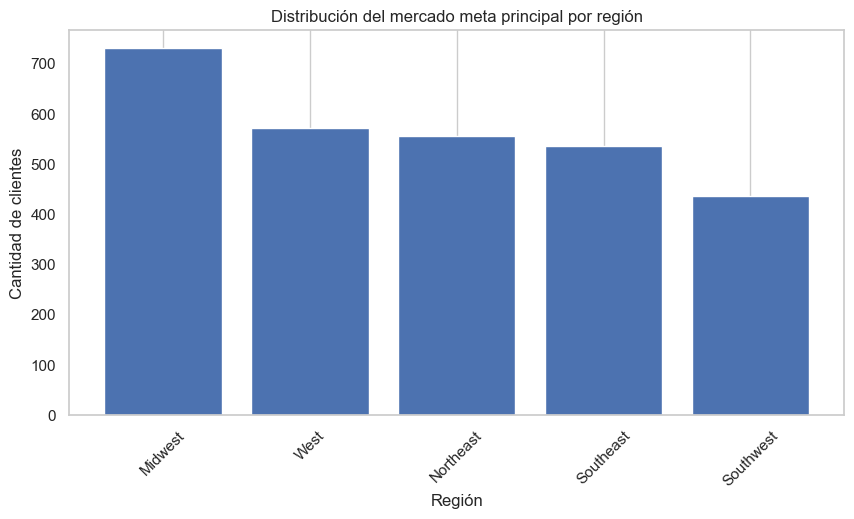

In [41]:
# Gráfico del mercado meta por región 

mercado_meta_region = mercado_meta["main_region"].value_counts().reset_index()
mercado_meta_region.columns = ["Región", "Cantidad de clientes"]

plt.figure(figsize=(10, 5))
plt.bar(
    mercado_meta_region["Región"],
    mercado_meta_region["Cantidad de clientes"]
)

plt.title("Distribución del mercado meta principal por región")
plt.xlabel("Región")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [42]:
# Resumen estratégico del mercado meta principal 

# Mostrar textos completos en las tablas
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Extraer principales características del mercado meta desde la tabla categórica
top_region = perfil_categorico_mercado_meta.loc[
    perfil_categorico_mercado_meta["Variable"] == "main_region", 
    "Categoría principal"
].values[0]

top_store_type = perfil_categorico_mercado_meta.loc[
    perfil_categorico_mercado_meta["Variable"] == "main_store_location_type", 
    "Categoría principal"
].values[0]

top_channel = perfil_categorico_mercado_meta.loc[
    perfil_categorico_mercado_meta["Variable"] == "main_order_channel", 
    "Categoría principal"
].values[0]

top_age_group = perfil_categorico_mercado_meta.loc[
    perfil_categorico_mercado_meta["Variable"] == "main_age_group", 
    "Categoría principal"
].values[0]

top_drink = perfil_categorico_mercado_meta.loc[
    perfil_categorico_mercado_meta["Variable"] == "main_drink_category", 
    "Categoría principal"
].values[0]

top_time_slot = perfil_categorico_mercado_meta.loc[
    perfil_categorico_mercado_meta["Variable"] == "main_time_slot", 
    "Categoría principal"
].values[0]

# Crear tabla resumen
resumen_estrategico = pd.DataFrame({
    "Elemento estratégico": [
        "Mercado meta principal",
        "Perfil dominante",
        "Región prioritaria",
        "Tipo de tienda prioritario",
        "Canal prioritario",
        "Grupo etario principal",
        "Producto principal",
        "Horario de mayor consumo"
    ],
    "Resultado del análisis": [
        "Clientes de alto valor RFM pertenecientes al segmento socio-demográfico 0",
        "Clientes digitales de consumo ampliado",
        top_region,
        top_store_type,
        top_channel,
        top_age_group,
        top_drink,
        top_time_slot
    ]
})

display(resumen_estrategico)

,Elemento estratégico,Resultado del análisis
0,Mercado meta principal,Clientes de alto valor RFM pertenecientes al segmento socio-demográfico 0
1,Perfil dominante,Clientes digitales de consumo ampliado
2,Región prioritaria,Midwest
3,Tipo de tienda prioritario,Suburban
4,Canal prioritario,Mobile App
5,Grupo etario principal,25-34
6,Producto principal,Brewed Coffee
7,Horario de mayor consumo,Mañana


## Recomendaciones de posicionamiento

En esta sección se presentan recomendaciones estratégicas a partir de los resultados obtenidos en los modelos de segmentación. Las recomendaciones se orientan a definir el mercado meta principal, priorizar canales de atención, identificar oportunidades de localización y proponer una estrategia de posicionamiento para Starbucks America.

In [43]:
# Recomendaciones de posicionamiento

# Mostrar textos completos en las tablas
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

recomendaciones_posicionamiento = pd.DataFrame({
    "Dimensión": [
        "Segmento objetivo",
        "Localización",
        "Canal de atención",
        "Propuesta de valor",
        "Promociones",
        "Producto",
        "Experiencia de compra",
        "Fidelización"
    ],
    "Recomendación": [
        "Priorizar clientes de alto valor con perfil digital y mayor consumo por pedido",
        f"Evaluar expansión principalmente en zonas {top_store_type} de la región {top_region}",
        f"Fortalecer el canal {top_channel}, especialmente para pedidos anticipados",
        "Posicionar Starbucks como una opción rápida, conveniente y personalizable para consumo diario",
        "Diseñar promociones combinadas de café y comida para aumentar ticket y carrito promedio",
        f"Utilizar {top_drink} como producto base para campañas, complementado con alimentos",
        f"Optimizar la operación durante el horario de {top_time_slot}, donde se concentra mayor demanda",
        "Reforzar el programa Rewards para aumentar recurrencia y retención de clientes valiosos"
    ]
})

display(recomendaciones_posicionamiento)

,Dimensión,Recomendación
0,Segmento objetivo,Priorizar clientes de alto valor con perfil digital y mayor consumo por pedido
1,Localización,Evaluar expansión principalmente en zonas Suburban de la región Midwest
2,Canal de atención,"Fortalecer el canal Mobile App, especialmente para pedidos anticipados"
3,Propuesta de valor,"Posicionar Starbucks como una opción rápida, conveniente y personalizable para consumo diario"
4,Promociones,Diseñar promociones combinadas de café y comida para aumentar ticket y carrito promedio
5,Producto,"Utilizar Brewed Coffee como producto base para campañas, complementado con alimentos"
6,Experiencia de compra,"Optimizar la operación durante el horario de Mañana, donde se concentra mayor demanda"
7,Fidelización,Reforzar el programa Rewards para aumentar recurrencia y retención de clientes valiosos


In [44]:
# Ranking de oportunidades de expansión 

ranking_expansion = mercado_meta_region_tienda.copy()

ranking_expansion["ranking_oportunidad"] = ranking_expansion["clientes"].rank(
    method="dense",
    ascending=False
).astype(int)

ranking_expansion = ranking_expansion.sort_values("ranking_oportunidad")

ranking_expansion = ranking_expansion[
    [
        "ranking_oportunidad",
        "main_region",
        "main_store_location_type",
        "clientes",
        "Porcentaje_clientes",
        "ticket_promedio",
        "monetary_promedio",
        "satisfaccion_promedio"
    ]
]

display(ranking_expansion)

,ranking_oportunidad,main_region,main_store_location_type,clientes,Porcentaje_clientes,ticket_promedio,monetary_promedio,satisfaccion_promedio
1,1,Midwest,Suburban,286,10.12,16.61,149.32,3.71
0,2,Midwest,Rural,255,9.02,16.57,146.14,3.76
12,3,West,Rural,230,8.14,16.69,153.46,3.74
13,4,West,Suburban,220,7.78,16.62,151.75,3.75
7,5,Southeast,Suburban,214,7.57,16.38,149.80,3.72
6,6,Southeast,Rural,207,7.32,16.70,153.55,3.76
4,7,Northeast,Suburban,199,7.04,16.69,152.18,3.79
10,8,Southwest,Suburban,197,6.97,16.50,156.48,3.74
3,9,Northeast,Rural,190,6.72,16.58,149.98,3.72
2,10,Midwest,Urban,189,6.69,16.62,154.78,3.73


El ranking de oportunidades de expansión permite identificar las combinaciones de región y tipo de tienda con mayor presencia del mercado meta principal. La principal oportunidad se observa en Midwest Suburban, seguida por Midwest Rural, West Rural y West Suburban.

Estas combinaciones pueden servir como referencia para evaluar nuevas franquicias, campañas focalizadas o refuerzo de capacidad operativa en zonas con mayor concentración de clientes valiosos.

## Conclusiones

In [45]:
# Conclusión final de análisis

print("CONCLUSIÓN FINAL DEL ANÁLISIS DE SEGMENTACIÓN")
print("-" * 60)

print("\n1. Mercado meta principal:")
print("El mercado meta principal corresponde a clientes de alto valor RFM que pertenecen")
print("al segmento socio-demográfico 0, definido como clientes digitales de consumo ampliado.")

print("\n2. Perfil del mercado meta:")
print("- Región principal: Midwest")
print("- Tipo de tienda principal: Suburban")
print("- Canal dominante: Mobile App")
print("- Grupo etario principal: 25-34")
print("- Producto principal: Brewed Coffee")
print("- Horario dominante: Mañana")
print("- Mayor vínculo con Rewards y mayor uso de pedido anticipado")

print("\n3. Lectura estratégica:")
print("El modelo RFM permitió identificar a los clientes con mayor valor comercial, mientras que")
print("el modelo socio-demográfico permitió describir su perfil de consumo, canal preferente")
print("y ubicación dominante. Al cruzar ambos modelos, se observa que el perfil digital de")
print("consumo ampliado tiene mayor presencia dentro de los clientes de alto valor.")

print("\n4. Recomendación de posicionamiento:")
print("Se recomienda posicionar Starbucks como una alternativa de conveniencia digital,")
print("rápida y personalizable, orientada a consumidores de alto valor que utilizan Mobile App,")
print("realizan pedidos anticipados y concentran su consumo durante la mañana.")

print("\n5. Recomendación para expansión:")
print("Se sugiere priorizar oportunidades de apertura en zonas suburbanas de la región Midwest,")
print("ya que esta combinación concentra la mayor proporción del mercado meta principal.")
print("Como alternativas secundarias, también pueden evaluarse zonas rurales de Midwest y")
print("zonas rurales/suburbanas de West, debido a su presencia relevante dentro del mercado meta.")

print("\n6. Acciones comerciales sugeridas:")
print("- Potenciar campañas por Mobile App.")
print("- Diseñar promociones matutinas.")
print("- Fortalecer el programa Rewards.")
print("- Ofrecer combos de Brewed Coffee con alimentos.")
print("- Optimizar la experiencia de compra anticipada y personalizada.")

CONCLUSIÓN FINAL DEL ANÁLISIS DE SEGMENTACIÓN
------------------------------------------------------------

1. Mercado meta principal:
El mercado meta principal corresponde a clientes de alto valor RFM que pertenecen
al segmento socio-demográfico 0, definido como clientes digitales de consumo ampliado.

2. Perfil del mercado meta:
- Región principal: Midwest
- Tipo de tienda principal: Suburban
- Canal dominante: Mobile App
- Grupo etario principal: 25-34
- Producto principal: Brewed Coffee
- Horario dominante: Mañana
- Mayor vínculo con Rewards y mayor uso de pedido anticipado

3. Lectura estratégica:
El modelo RFM permitió identificar a los clientes con mayor valor comercial, mientras que
el modelo socio-demográfico permitió describir su perfil de consumo, canal preferente
y ubicación dominante. Al cruzar ambos modelos, se observa que el perfil digital de
consumo ampliado tiene mayor presencia dentro de los clientes de alto valor.

4. Recomendación de posicionamiento:
Se recomienda p